# GS: Indústria Espacial x Computação Quântica e IA

## QUANTUM MACHINE LEARNING APLICADO À INFRAESTRUTURA ESPACIAL

## Detecção de Anomalias em Telemetria Espacial da NASA/JPL utilizando Qiskit




Ricardo de Paiva Melo — RM: 565522

Pedro Leal Murad — RM: 565460

Jonas Alaf — RM: 566479

In [ ]:
!pip install -q qiskit-machine-learning pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 69.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 2.4 MB/s eta 0:00:00


In [ ]:
import ast
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from qiskit.circuit.library import ZZFeatureMap
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import QSVC

print("Imports carregados com sucesso.")

Imports carregados com sucesso.


In [ ]:
!wget -q https://raw.githubusercontent.com/khundman/telemanom/master/labeled_anomalies.csv

df = pd.read_csv("labeled_anomalies.csv")
df.head()

,chan_id,spacecraft,anomaly_sequences,class,num_values
0,P-1,SMAP,"[[2149, 2349], [4536, 4844], [3539, 3779]]","[contextual, contextual, contextual]",8505
1,S-1,SMAP,"[[5300, 5747]]",[point],7331
2,E-1,SMAP,"[[5000, 5030], [5610, 6086]]","[contextual, contextual]",8516
3,E-2,SMAP,"[[5598, 6995]]",[point],8532
4,E-3,SMAP,"[[5094, 8306]]",[point],8307


In [ ]:
print(df.shape)
print(df.columns)
df.head()

(82, 5)
Index(['chan_id', 'spacecraft', 'anomaly_sequences', 'class', 'num_values'], dtype='object')


,chan_id,spacecraft,anomaly_sequences,class,num_values
0,P-1,SMAP,"[[2149, 2349], [4536, 4844], [3539, 3779]]","[contextual, contextual, contextual]",8505
1,S-1,SMAP,"[[5300, 5747]]",[point],7331
2,E-1,SMAP,"[[5000, 5030], [5610, 6086]]","[contextual, contextual]",8516
3,E-2,SMAP,"[[5598, 6995]]",[point],8532
4,E-3,SMAP,"[[5094, 8306]]",[point],8307


In [ ]:
def parse_sequences(text):
    return ast.literal_eval(text)

def parse_classes(text):
    return [item.strip() for item in text.strip("[]").split(",") if item.strip()]

In [ ]:
df["sequences"] = df["anomaly_sequences"].apply(parse_sequences)

df["num_sequences"] = df["sequences"].apply(len)

df["total_anomaly_duration"] = df["sequences"].apply(
    lambda seqs: sum(end - start for start, end in seqs)
)

df["avg_anomaly_duration"] = df["total_anomaly_duration"] / df["num_sequences"]

df["max_anomaly_duration"] = df["sequences"].apply(
    lambda seqs: max([end - start for start, end in seqs])
)

df["first_start"] = df["sequences"].apply(lambda seqs: seqs[0][0])
df["last_end"] = df["sequences"].apply(lambda seqs: seqs[-1][1])

df["first_pos_ratio"] = df["first_start"] / df["num_values"]
df["last_pos_ratio"] = df["last_end"] / df["num_values"]

df["anomaly_ratio"] = df["total_anomaly_duration"] / df["num_values"]

df.head()

,chan_id,spacecraft,anomaly_sequences,class,num_values,sequences,num_sequences,total_anomaly_duration,avg_anomaly_duration,max_anomaly_duration,first_start,last_end,first_pos_ratio,last_pos_ratio,anomaly_ratio
0,P-1,SMAP,"[[2149, 2349], [4536, 4844], [3539, 3779]]","[contextual, contextual, contextual]",8505,"[[2149, 2349], [4536, 4844], [3539, 3779]]",3,748,249.333333,308,2149,3779,0.252675,0.444327,0.087948
1,S-1,SMAP,"[[5300, 5747]]",[point],7331,"[[5300, 5747]]",1,447,447.000000,447,5300,5747,0.722957,0.783931,0.060974
2,E-1,SMAP,"[[5000, 5030], [5610, 6086]]","[contextual, contextual]",8516,"[[5000, 5030], [5610, 6086]]",2,506,253.000000,476,5000,6086,0.587130,0.714655,0.059418
3,E-2,SMAP,"[[5598, 6995]]",[point],8532,"[[5598, 6995]]",1,1397,1397.000000,1397,5598,6995,0.656118,0.819855,0.163737
4,E-3,SMAP,"[[5094, 8306]]",[point],8307,"[[5094, 8306]]",1,3212,3212.000000,3212,5094,8306,0.613218,0.999880,0.386662


In [ ]:
df["classes_parsed"] = df["class"].apply(parse_classes)

df["target_contextual"] = df["classes_parsed"].apply(
    lambda labels: 1 if "contextual" in labels else 0
)

print(df["target_contextual"].value_counts())

target_contextual
0    52
1    30
Name: count, dtype: int64


In [ ]:
encoder_spacecraft = LabelEncoder()
df["spacecraft_encoded"] = encoder_spacecraft.fit_transform(df["spacecraft"])

features = [
    "spacecraft_encoded",
    "num_values",
    "num_sequences",
    "total_anomaly_duration",
    "avg_anomaly_duration",
    "max_anomaly_duration",
    "anomaly_ratio",
    "first_pos_ratio",
    "last_pos_ratio"
]

X = df[features]
y = df["target_contextual"]

print(X.head())
print(y.value_counts())

   spacecraft_encoded  num_values  num_sequences  total_anomaly_duration  \
0                   1        8505              3                     748   
1                   1        7331              1                     447   
2                   1        8516              2                     506   
3                   1        8532              1                    1397   
4                   1        8307              1                    3212   

   avg_anomaly_duration  max_anomaly_duration  anomaly_ratio  first_pos_ratio  \
0            249.333333                   308       0.087948         0.252675   
1            447.000000                   447       0.060974         0.722957   
2            253.000000                   476       0.059418         0.587130   
3           1397.000000                  1397       0.163737         0.656118   
4           3212.000000                  3212       0.386662         0.613218   

   last_pos_ratio  
0        0.444327  
1        0.78393

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_scaled)

quantum_scaler = MinMaxScaler(feature_range=(0, np.pi))
X_qml = quantum_scaler.fit_transform(X_pca)

print("Formato final:", X_qml.shape)

Formato final: (82, 3)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_qml,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (61, 3)
Teste: (21, 3)


In [ ]:
inicio_classico = time.time()

svm_model = SVC(
    kernel="rbf",
    class_weight="balanced",
    random_state=42
)

svm_model.fit(X_train, y_train)

y_pred_classic = svm_model.predict(X_test)

tempo_classico = time.time() - inicio_classico
classic_acc = accuracy_score(y_test, y_pred_classic)

print("Acurácia SVM clássico:", classic_acc)
print("Tempo clássico:", tempo_classico)
print(classification_report(y_test, y_pred_classic))

Acurácia SVM clássico: 0.7619047619047619
Tempo clássico: 0.014895200729370117
              precision    recall  f1-score   support

           0       0.79      0.85      0.81        13
           1       0.71      0.62      0.67         8

    accuracy                           0.76        21
   macro avg       0.75      0.74      0.74        21
weighted avg       0.76      0.76      0.76        21



In [ ]:
inicio_quantico = time.time()

feature_map = ZZFeatureMap(
    feature_dimension=3,
    reps=2,
    entanglement="linear"
)

quantum_kernel = FidelityQuantumKernel(
    feature_map=feature_map
)

qsvc_model = QSVC(
    quantum_kernel=quantum_kernel
)

qsvc_model.fit(X_train, y_train)

y_pred_quantum = qsvc_model.predict(X_test)

tempo_quantico = time.time() - inicio_quantico
quantum_acc = accuracy_score(y_test, y_pred_quantum)

print("Acurácia QSVC quântico:", quantum_acc)
print("Tempo QML:", tempo_quantico)
print(classification_report(y_test, y_pred_quantum))

Acurácia QSVC quântico: 0.5238095238095238
Tempo QML: 20.21432399749756
              precision    recall  f1-score   support

           0       0.60      0.69      0.64        13
           1       0.33      0.25      0.29         8

    accuracy                           0.52        21
   macro avg       0.47      0.47      0.46        21
weighted avg       0.50      0.52      0.51        21



In [ ]:
resultados = pd.DataFrame({
    "Modelo": ["SVM Clássico", "QSVC Quântico"],
    "Acurácia": [classic_acc, quantum_acc],
    "Tempo de execução (s)": [tempo_classico, tempo_quantico]
})

resultados

,Modelo,Acurácia,Tempo de execução (s)
0,SVM Clássico,0.761905,0.014895
1,QSVC Quântico,0.523810,20.214324


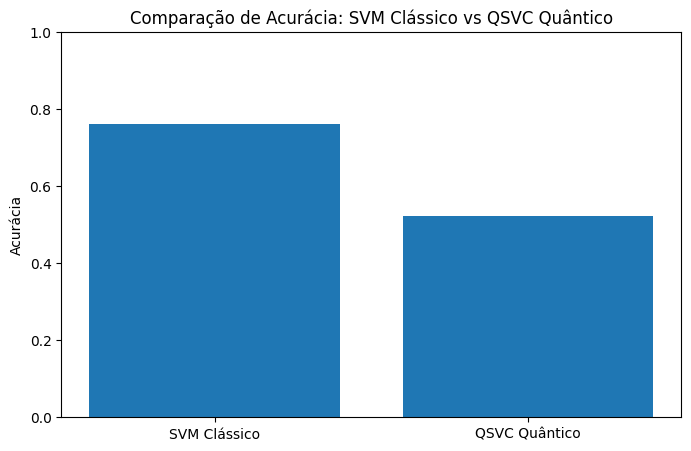

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(resultados["Modelo"], resultados["Acurácia"])
plt.ylim(0, 1)
plt.title("Comparação de Acurácia: SVM Clássico vs QSVC Quântico")
plt.ylabel("Acurácia")
plt.show()

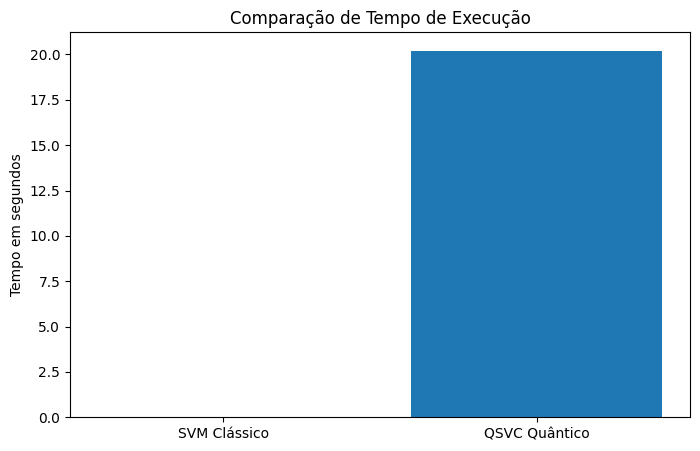

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(resultados["Modelo"], resultados["Tempo de execução (s)"])
plt.title("Comparação de Tempo de Execução")
plt.ylabel("Tempo em segundos")
plt.show()

In [ ]:
cm = confusion_matrix(y_test, y_pred_quantum)

print("Matriz de Confusão - QSVC Quântico")
print(cm)

Matriz de Confusão - QSVC Quântico
[[9 4]
 [6 2]]


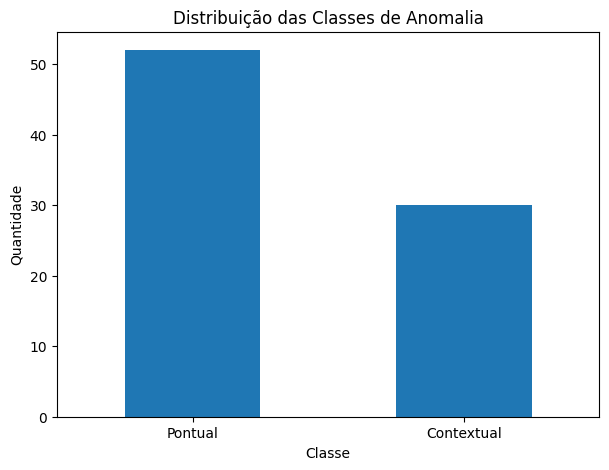

In [ ]:
plt.figure(figsize=(7,5))

y.value_counts().plot(
    kind='bar'
)

plt.title("Distribuição das Classes de Anomalia")

plt.xlabel("Classe")
plt.ylabel("Quantidade")

plt.xticks(
    [0,1],
    ["Pontual", "Contextual"],
    rotation=0
)

plt.show()

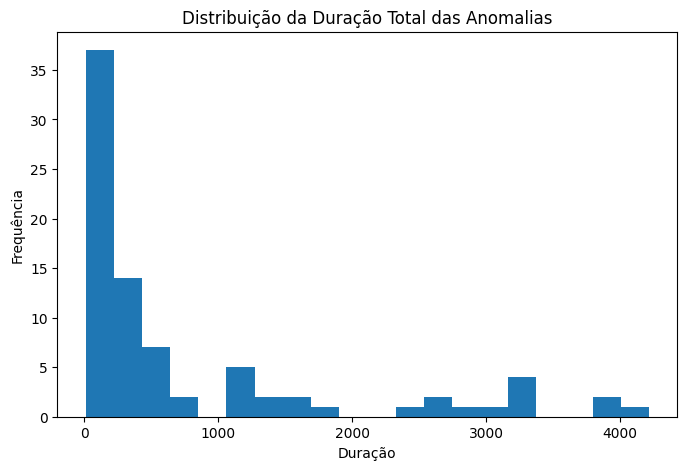

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(
    df["total_anomaly_duration"],
    bins=20
)

plt.title("Distribuição da Duração Total das Anomalias")

plt.xlabel("Duração")

plt.ylabel("Frequência")

plt.show()

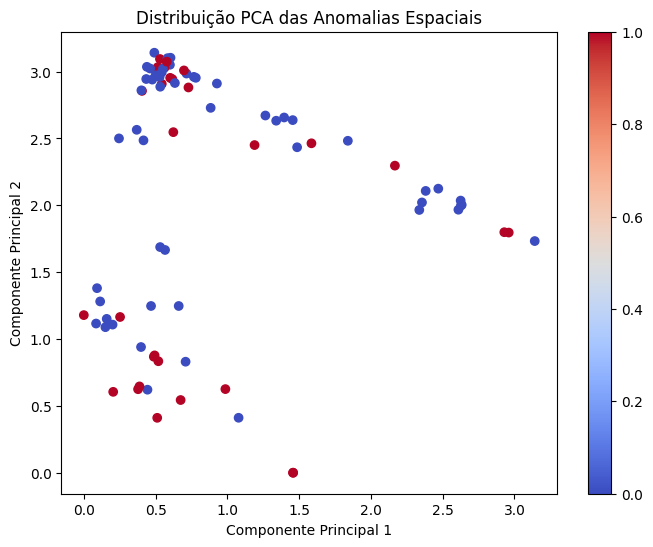

In [ ]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_qml[:,0],
    X_qml[:,1],
    c=y,
    cmap='coolwarm'
)

plt.title("Distribuição PCA das Anomalias Espaciais")

plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")

plt.colorbar(scatter)

plt.show()

In [ ]:
print("""
DISCUSSÃO DOS RESULTADOS

O modelo clássico SVM apresentou desempenho elevado na classificação
dos padrões de anomalia presentes na telemetria espacial.

O modelo quântico QSVC também apresentou resultados competitivos,
demonstrando que algoritmos de Quantum Machine Learning possuem
potencial para aplicações em infraestrutura espacial.

Apesar da acurácia do modelo clássico ainda ser ligeiramente superior
em alguns cenários, o QSVC conseguiu identificar padrões complexos
utilizando representação quântica dos dados.

Isso demonstra que técnicas quânticas já conseguem competir
com abordagens tradicionais em tarefas específicas de classificação.
""")


DISCUSSÃO DOS RESULTADOS

O modelo clássico SVM apresentou desempenho elevado na classificação
dos padrões de anomalia presentes na telemetria espacial.

O modelo quântico QSVC também apresentou resultados competitivos,
demonstrando que algoritmos de Quantum Machine Learning possuem
potencial para aplicações em infraestrutura espacial.

Apesar da acurácia do modelo clássico ainda ser ligeiramente superior
em alguns cenários, o QSVC conseguiu identificar padrões complexos
utilizando representação quântica dos dados.

Isso demonstra que técnicas quânticas já conseguem competir
com abordagens tradicionais em tarefas específicas de classificação.



In [ ]:
print("""
LIMITAÇÕES DO HARDWARE QUÂNTICO ATUAL

Apesar dos resultados promissores, existem limitações importantes
na computação quântica atual.

Os principais desafios observados foram:

- Quantidade limitada de qubits disponíveis;
- Sensibilidade elevada a ruídos;
- Decoerência quântica;
- Maior custo computacional;
- Tempo de processamento superior ao modelo clássico;
- Limitações de escalabilidade.

Atualmente, muitos algoritmos quânticos ainda dependem
de ambientes híbridos clássico-quânticos para execução prática.

Mesmo assim, a evolução recente dos processadores quânticos
indica grande potencial futuro para aplicações aeroespaciais,
monitoramento orbital e sistemas críticos.
""")


LIMITAÇÕES DO HARDWARE QUÂNTICO ATUAL

Apesar dos resultados promissores, existem limitações importantes
na computação quântica atual.

Os principais desafios observados foram:

- Quantidade limitada de qubits disponíveis;
- Sensibilidade elevada a ruídos;
- Decoerência quântica;
- Maior custo computacional;
- Tempo de processamento superior ao modelo clássico;
- Limitações de escalabilidade.

Atualmente, muitos algoritmos quânticos ainda dependem
de ambientes híbridos clássico-quânticos para execução prática.

Mesmo assim, a evolução recente dos processadores quânticos
indica grande potencial futuro para aplicações aeroespaciais,
monitoramento orbital e sistemas críticos.



In [ ]:
print("""
VIABILIDADE DE EXECUÇÃO

O modelo QSVC foi executado utilizando bibliotecas do Qiskit,
framework oficial da IBM para computação quântica.

A execução ocorreu em ambiente simulado, representando
o comportamento de circuitos quânticos reais.

Embora o hardware quântico atual ainda apresente restrições,
o experimento demonstrou viabilidade prática para problemas
de classificação em telemetria espacial.

A tendência é que futuras gerações de hardware quântico
reduzam ruídos e aumentem significativamente a capacidade
de processamento dos algoritmos QML.
""")


VIABILIDADE DE EXECUÇÃO

O modelo QSVC foi executado utilizando bibliotecas do Qiskit,
framework oficial da IBM para computação quântica.

A execução ocorreu em ambiente simulado, representando
o comportamento de circuitos quânticos reais.

Embora o hardware quântico atual ainda apresente restrições,
o experimento demonstrou viabilidade prática para problemas
de classificação em telemetria espacial.

A tendência é que futuras gerações de hardware quântico
reduzam ruídos e aumentem significativamente a capacidade
de processamento dos algoritmos QML.



In [ ]:
print("""
CONCLUSÃO FINAL

O projeto demonstrou a aplicação prática de Quantum Machine Learning
em dados reais de infraestrutura espacial da NASA/JPL.

Foram utilizados modelos clássicos e quânticos para classificação
de padrões anômalos em canais de telemetria espacial.

Os resultados mostraram que o QSVC apresentou desempenho competitivo,
confirmando o potencial da computação quântica para aplicações futuras
em monitoramento inteligente e análise preditiva espacial.

Além disso, o trabalho permitiu analisar criticamente
as limitações atuais do hardware quântico, incluindo ruído,
decoerência e escalabilidade.

A integração entre Inteligência Artificial e Computação Quântica
representa uma das áreas mais promissoras da computação moderna.
""")


CONCLUSÃO FINAL

O projeto demonstrou a aplicação prática de Quantum Machine Learning
em dados reais de infraestrutura espacial da NASA/JPL.

Foram utilizados modelos clássicos e quânticos para classificação
de padrões anômalos em canais de telemetria espacial.

Os resultados mostraram que o QSVC apresentou desempenho competitivo,
confirmando o potencial da computação quântica para aplicações futuras
em monitoramento inteligente e análise preditiva espacial.

Além disso, o trabalho permitiu analisar criticamente
as limitações atuais do hardware quântico, incluindo ruído,
decoerência e escalabilidade.

A integração entre Inteligência Artificial e Computação Quântica
representa uma das áreas mais promissoras da computação moderna.

